# Membership

### 파일 불러오기

In [13]:
import pandas as pd

file_path_0 = r"C:\myCode\ott-churn-prediction\kim.kwangil\preprocessing\260509_promotion_split_v1\promotion_0_membership_v2.csv"

membership_0 = pd.read_csv(file_path_0)

file_path_1 = r"C:\myCode\ott-churn-prediction\kim.kwangil\preprocessing\260509_promotion_split_v1\promotion_1_membership_v2.csv"

membership_1 = pd.read_csv(file_path_1)

In [14]:
membership_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11955 entries, 0 to 11954
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   USER_KEY            11955 non-null  object 
 1   product_code        11955 non-null  object 
 2   price               11955 non-null  float64
 3   billing_method      11955 non-null  int64  
 4   max_screen          11955 non-null  float64
 5   is_promotion        11955 non-null  int64  
 6   is_churn_prevented  11955 non-null  int64  
 7   payment_device      11955 non-null  object 
 8   is_user_verified    11955 non-null  int64  
 9   gender              11955 non-null  object 
 10  age                 11955 non-null  float64
 11  reg_date            11955 non-null  object 
 12  reg_hour            11955 non-null  int64  
 13  end_date            11955 non-null  object 
 14  is_repurchase       11955 non-null  int64  
dtypes: float64(3), int64(6), object(6)
memory usage: 1.4+

### gender x age

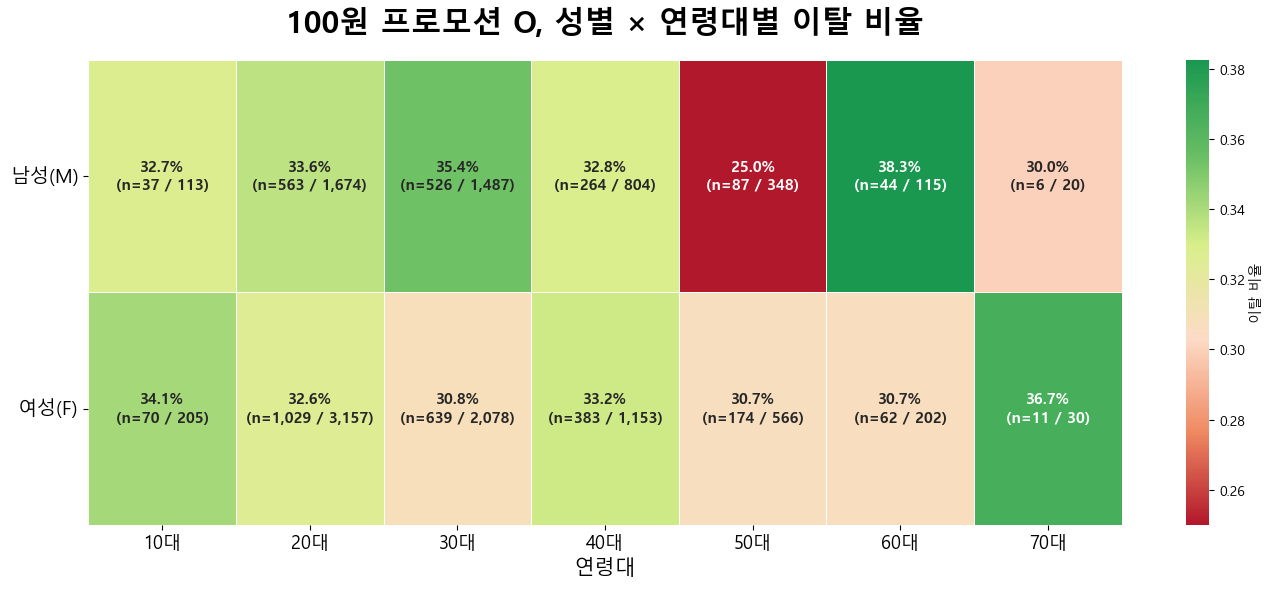

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 원본 복사
df = membership_1.copy()

# 분석 대상 행 필터링
df = df[df["gender"].notna() & df["age"].notna() & df["is_repurchase"].notna()].copy()

# 연령대 구간 설정
age_bins = [10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# 성별 표기 통일
gender_map = {
    "M": "남성(M)",
    "F": "여성(F)",
    "남성": "남성(M)",
    "여성": "여성(F)",
    "male": "남성(M)",
    "female": "여성(F)"
}
df["gender_label"] = df["gender"].replace(gender_map)

# 성별 순서 지정
df["gender_label"] = pd.Categorical(
    df["gender_label"],
    categories=["남성(M)", "여성(F)"],
    ordered=True
)

# 집계 테이블 생성
summary = (
    df.groupby(["gender_label", "age_group"], observed=False)["is_repurchase"]
    .agg(
        repurchase_cnt=lambda x: (x == 0).sum(),
        total_cnt="count"
    )
    .reset_index()
)

# 비율 계산
summary["repurchase_rate"] = summary["repurchase_cnt"] / summary["total_cnt"]

# 히트맵용 피벗 생성
heatmap_data = summary.pivot(
    index="gender_label",
    columns="age_group",
    values="repurchase_rate"
)

# 셀 표시 문구 생성
summary["label"] = summary.apply(
    lambda row: (
        f'{row["repurchase_rate"]:.1%}\n'
        f'(n={int(row["repurchase_cnt"]):,} / {int(row["total_cnt"]):,})'
    )
    if pd.notna(row["repurchase_rate"]) else "",
    axis=1
)

annot_data = summary.pivot(
    index="gender_label",
    columns="age_group",
    values="label"
)

# 색상 대비 강화를 위한 최소값/최대값 계산
vmin = np.nanmin(heatmap_data.values)
vmax = np.nanmax(heatmap_data.values)

# 값 차이가 너무 작을 때 대비용 여유폭 설정
if np.isclose(vmin, vmax):
    vmin = max(0, vmin - 0.05)
    vmax = min(1, vmax + 0.05)

# 빨강-노랑-초록 계열 컬러맵 설정
cmap = LinearSegmentedColormap.from_list(
    "custom_rgy",
    ["#b2182b", "#ef8a62", "#fddbc7", "#d9ef8b", "#66bd63", "#1a9850"]
)

# 시각화 생성
plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt="",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "이탈 비율"},
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)

# 제목 및 축 설정
ax.set_title("100원 프로모션 O, 성별 × 연령대별 이탈 비율", fontsize=22, pad=20, weight="bold")
ax.set_xlabel("연령대", fontsize=15)
ax.set_ylabel("", fontsize=15)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=14, rotation=0)

plt.tight_layout()
plt.show()


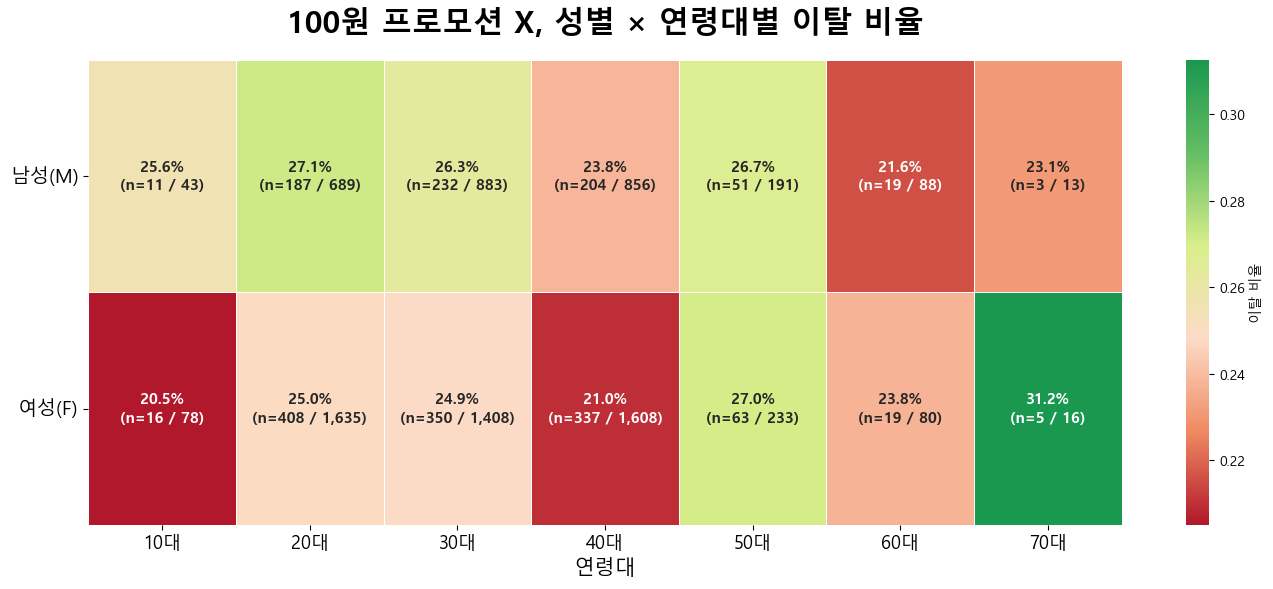

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 원본 복사
df = membership_0.copy()

# 분석 대상 행 필터링
df = df[df["gender"].notna() & df["age"].notna() & df["is_repurchase"].notna()].copy()

# 연령대 구간 설정
age_bins = [10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# 성별 표기 통일
gender_map = {
    "M": "남성(M)",
    "F": "여성(F)",
    "남성": "남성(M)",
    "여성": "여성(F)",
    "male": "남성(M)",
    "female": "여성(F)"
}
df["gender_label"] = df["gender"].replace(gender_map)

# 성별 순서 지정
df["gender_label"] = pd.Categorical(
    df["gender_label"],
    categories=["남성(M)", "여성(F)"],
    ordered=True
)

# 집계 테이블 생성
summary = (
    df.groupby(["gender_label", "age_group"], observed=False)["is_repurchase"]
    .agg(
        repurchase_cnt=lambda x: (x == 0).sum(),
        total_cnt="count"
    )
    .reset_index()
)

# 비율 계산
summary["repurchase_rate"] = summary["repurchase_cnt"] / summary["total_cnt"]

# 히트맵용 피벗 생성
heatmap_data = summary.pivot(
    index="gender_label",
    columns="age_group",
    values="repurchase_rate"
)

# 셀 표시 문구 생성
summary["label"] = summary.apply(
    lambda row: (
        f'{row["repurchase_rate"]:.1%}\n'
        f'(n={int(row["repurchase_cnt"]):,} / {int(row["total_cnt"]):,})'
    )
    if pd.notna(row["repurchase_rate"]) else "",
    axis=1
)

annot_data = summary.pivot(
    index="gender_label",
    columns="age_group",
    values="label"
)

# 색상 대비 강화를 위한 최소값/최대값 계산
vmin = np.nanmin(heatmap_data.values)
vmax = np.nanmax(heatmap_data.values)

# 값 차이가 너무 작을 때 대비용 여유폭 설정
if np.isclose(vmin, vmax):
    vmin = max(0, vmin - 0.05)
    vmax = min(1, vmax + 0.05)

# 빨강-노랑-초록 계열 컬러맵 설정
cmap = LinearSegmentedColormap.from_list(
    "custom_rgy",
    ["#b2182b", "#ef8a62", "#fddbc7", "#d9ef8b", "#66bd63", "#1a9850"]
)

# 시각화 생성
plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt="",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "이탈 비율"},
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)

# 제목 및 축 설정
ax.set_title("100원 프로모션 X, 성별 × 연령대별 이탈 비율", fontsize=22, pad=20, weight="bold")
ax.set_xlabel("연령대", fontsize=15)
ax.set_ylabel("", fontsize=15)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=14, rotation=0)

plt.tight_layout()
plt.show()


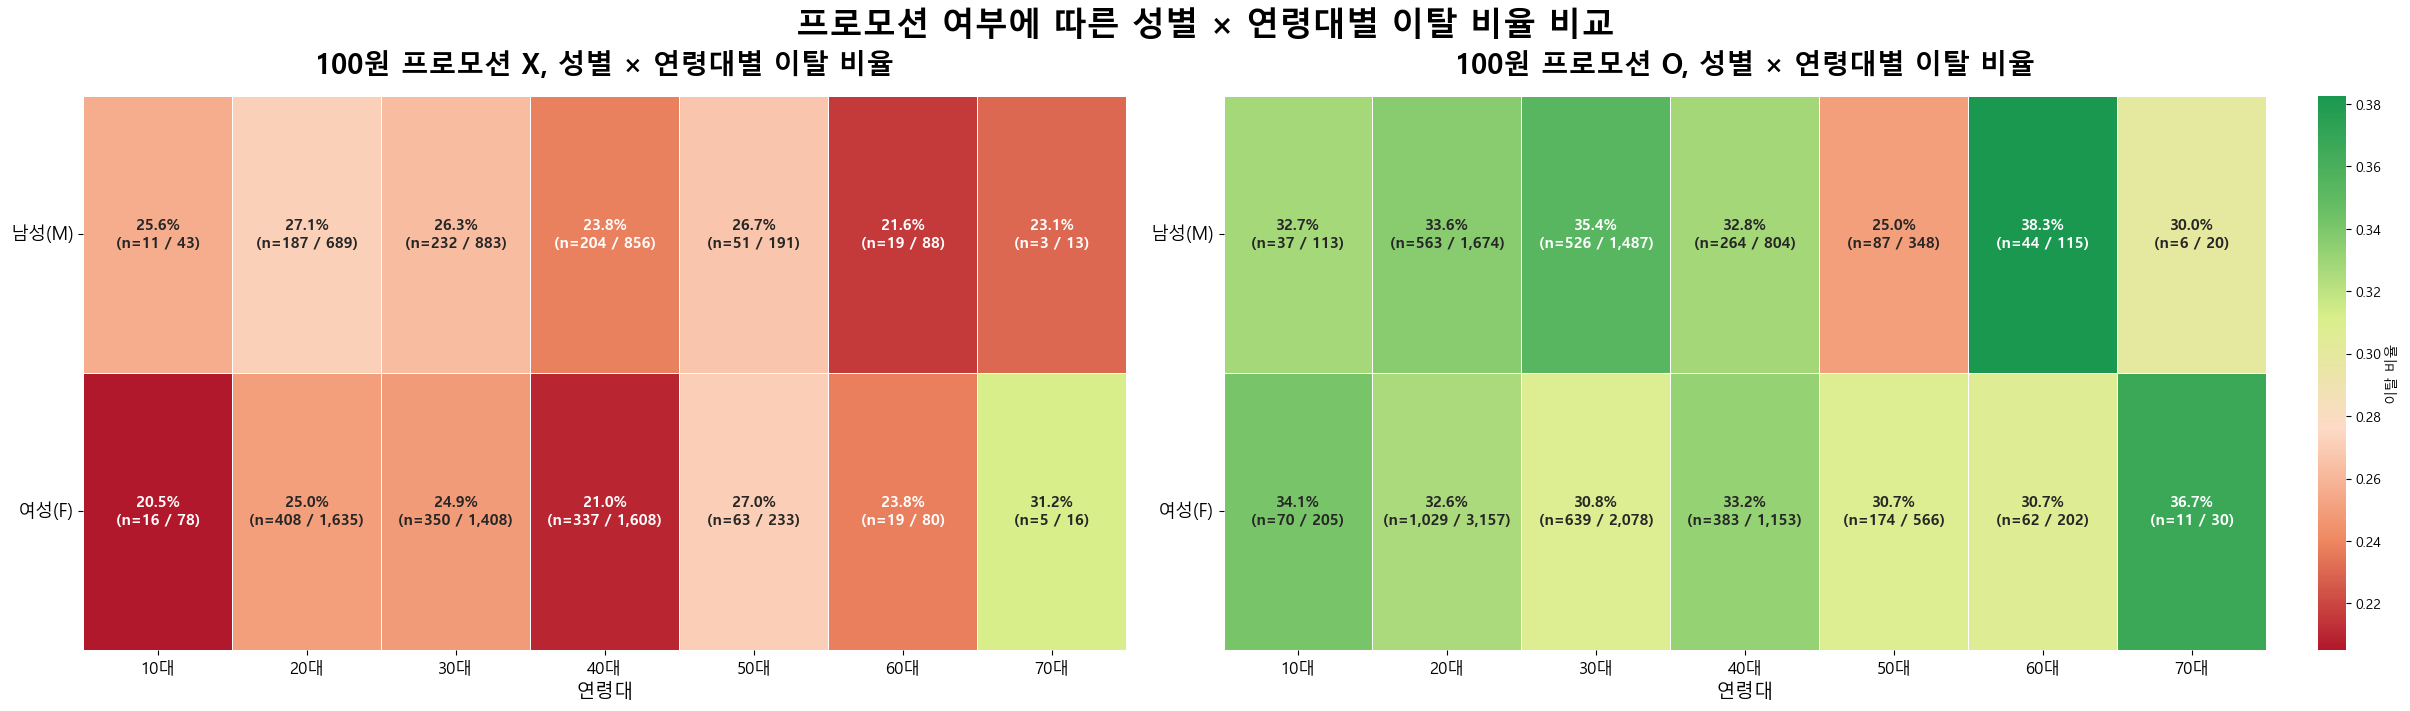

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 공통 컬러맵 설정
cmap = LinearSegmentedColormap.from_list(
    "custom_rgy",
    ["#b2182b", "#ef8a62", "#fddbc7", "#d9ef8b", "#66bd63", "#1a9850"]
)

# 성별 표기 매핑
gender_map = {
    "M": "남성(M)",
    "F": "여성(F)",
    "남성": "남성(M)",
    "여성": "여성(F)",
    "male": "남성(M)",
    "female": "여성(F)"
}

# 연령대 구간 정의
age_bins = [10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]


def prepare_heatmap_data(df, event_value=0):
    # 기본 전처리
    temp = df.copy()
    temp = temp[temp["gender"].notna() & temp["age"].notna() & temp["is_repurchase"].notna()].copy()

    # 연령대 생성
    temp["age_group"] = pd.cut(
        temp["age"],
        bins=age_bins,
        labels=age_labels,
        right=False
    )

    # 성별 표기 통일
    temp["gender_label"] = temp["gender"].replace(gender_map)
    temp["gender_label"] = pd.Categorical(
        temp["gender_label"],
        categories=["남성(M)", "여성(F)"],
        ordered=True
    )

    # 집계 테이블 생성
    summary = (
        temp.groupby(["gender_label", "age_group"], observed=False)["is_repurchase"]
        .agg(
            event_cnt=lambda x: (x == event_value).sum(),
            total_cnt="count"
        )
        .reset_index()
    )

    # 비율 계산
    summary["rate"] = summary["event_cnt"] / summary["total_cnt"]

    # 히트맵 데이터 생성
    heatmap_data = summary.pivot(
        index="gender_label",
        columns="age_group",
        values="rate"
    )

    # 셀 텍스트 생성
    summary["label"] = summary.apply(
        lambda row: (
            f'{row["rate"]:.1%}\n'
            f'(n={int(row["event_cnt"]):,} / {int(row["total_cnt"]):,})'
        ) if pd.notna(row["rate"]) else "",
        axis=1
    )

    annot_data = summary.pivot(
        index="gender_label",
        columns="age_group",
        values="label"
    )

    return heatmap_data, annot_data


# 비교 대상 데이터 준비
# event_value=0 -> 이탈 비율 기준
heatmap_0, annot_0 = prepare_heatmap_data(membership_0, event_value=0)
heatmap_1, annot_1 = prepare_heatmap_data(membership_1, event_value=0)

# 두 그림의 색상 범위 통일
combined_values = np.concatenate([
    heatmap_0.values.flatten(),
    heatmap_1.values.flatten()
])
combined_values = combined_values[~np.isnan(combined_values)]

vmin = combined_values.min()
vmax = combined_values.max()

if np.isclose(vmin, vmax):
    vmin = max(0, vmin - 0.05)
    vmax = min(1, vmax + 0.05)

# 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(24, 7), constrained_layout=True)

# 왼쪽 히트맵
sns.heatmap(
    heatmap_0,
    annot=annot_0,
    fmt="",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    ax=axes[0],
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)
axes[0].set_title("100원 프로모션 X, 성별 × 연령대별 이탈 비율", fontsize=20, pad=16, weight="bold")
axes[0].set_xlabel("연령대", fontsize=14)
axes[0].set_ylabel("", fontsize=14)
axes[0].tick_params(axis="x", labelsize=12)
axes[0].tick_params(axis="y", labelsize=13, rotation=0)

# 오른쪽 히트맵
hm = sns.heatmap(
    heatmap_1,
    annot=annot_1,
    fmt="",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "이탈 비율"},
    ax=axes[1],
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)
axes[1].set_title("100원 프로모션 O, 성별 × 연령대별 이탈 비율", fontsize=20, pad=16, weight="bold")
axes[1].set_xlabel("연령대", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].tick_params(axis="x", labelsize=12)
axes[1].tick_params(axis="y", labelsize=13, rotation=0)

# 전체 제목
fig.suptitle("프로모션 여부에 따른 성별 × 연령대별 이탈 비율 비교", fontsize=24, weight="bold")

plt.show()


In [18]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05
confidence_level = int((1 - alpha) * 100)

age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

gender_map = {
    "M": "남성(M)",
    "F": "여성(F)",
    "남성": "남성(M)",
    "여성": "여성(F)",
    "male": "남성(M)",
    "female": "여성(F)"
}

def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["gender"].notna() &
        temp["age"].notna() &
        temp["is_repurchase"].notna()
    ].copy()

    temp["gender_label"] = temp["gender"].replace(gender_map)
    temp = temp[temp["gender_label"].isin(["남성(M)", "여성(F)"])].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp = temp[temp["age"].notna()].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    # is_repurchase가 0인 경우를 이탈이라고 판단해서 churn 이라는 새로운 컬럼 생성

    temp["churn"] = (temp["is_repurchase"].astype(int) == 0).astype(int)

    return temp

def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

df0 = preprocess(membership_0)
df1 = preprocess(membership_1)

g0 = (
    df0.groupby(["gender_label", "age_group"], observed=False)["churn"]
    .agg(churn_n="sum", total_n="count")
    .reset_index()
    .rename(columns={"churn_n": "churn_0", "total_n": "total_0"})
)

g1 = (
    df1.groupby(["gender_label", "age_group"], observed=False)["churn"]
    .agg(churn_n="sum", total_n="count")
    .reset_index()
    .rename(columns={"churn_n": "churn_1", "total_n": "total_1"})
)

merged = pd.merge(g0, g1, on=["gender_label", "age_group"], how="inner")

merged["gender_label"] = pd.Categorical(
    merged["gender_label"],
    categories=["남성(M)", "여성(F)"],
    ordered=True
)
merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=age_labels,
    ordered=True
)
merged = merged.sort_values(["gender_label", "age_group"]).reset_index(drop=True)

significant_lines = []

for _, row in merged.iterrows():
    churn_0 = int(row["churn_0"])
    total_0 = int(row["total_0"])
    churn_1 = int(row["churn_1"])
    total_1 = int(row["total_1"])

    rate_0 = churn_0 / total_0
    rate_1 = churn_1 / total_1
    pvalue, test_name = run_test(churn_0, total_0, churn_1, total_1)

    if pvalue < alpha:
        line = (
            f"{row['gender_label']} {row['age_group']} | "
            f"프로모션 X: {rate_0:.1%} | "
            f"프로모션 O: {rate_1:.1%} | "
            f"p-value={pvalue:.6g} | "
            f"검정법={test_name}"
        )
        significant_lines.append(line)

print(f"{confidence_level}% 신뢰수준에서 유의미하게 차이가 있는 구간")

if significant_lines:
    for line in significant_lines:
        print(line)
else:
    print("없음")


95% 신뢰수준에서 유의미하게 차이가 있는 구간
남성(M) 20대 | 프로모션 X: 27.1% | 프로모션 O: 33.6% | p-value=0.00206272 | 검정법=Two-proportion z-test
남성(M) 30대 | 프로모션 X: 26.3% | 프로모션 O: 35.4% | p-value=4.3918e-06 | 검정법=Two-proportion z-test
남성(M) 40대 | 프로모션 X: 23.8% | 프로모션 O: 32.8% | p-value=4.60738e-05 | 검정법=Two-proportion z-test
남성(M) 60대 | 프로모션 X: 21.6% | 프로모션 O: 38.3% | p-value=0.0109552 | 검정법=Two-proportion z-test
여성(F) 10대 | 프로모션 X: 20.5% | 프로모션 O: 34.1% | p-value=0.025871 | 검정법=Two-proportion z-test
여성(F) 20대 | 프로모션 X: 25.0% | 프로모션 O: 32.6% | p-value=4.43934e-08 | 검정법=Two-proportion z-test
여성(F) 30대 | 프로모션 X: 24.9% | 프로모션 O: 30.8% | p-value=0.000152454 | 검정법=Two-proportion z-test
여성(F) 40대 | 프로모션 X: 21.0% | 프로모션 O: 33.2% | p-value=4.6243e-13 | 검정법=Two-proportion z-test


In [19]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05
confidence_level = int((1 - alpha) * 100)

age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]
target_age_groups = ["20대", "30대", "50대"]

gender_map = {
    "M": "남성(M)",
    "F": "여성(F)",
    "남성": "남성(M)",
    "여성": "여성(F)",
    "male": "남성(M)",
    "female": "여성(F)"
}

def preprocess_for_prevented(df):
    temp = df.copy()

    # 결측 제거
    temp = temp[
        temp["gender"].notna() &
        temp["age"].notna() &
        temp["is_churn_prevented"].notna()
    ].copy()

    # 성별 정규화
    temp["gender_label"] = temp["gender"].replace(gender_map)
    temp = temp[temp["gender_label"].isin(["남성(M)", "여성(F)"])].copy()

    # 나이 숫자형 변환
    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp = temp[temp["age"].notna()].copy()

    # 연령대 구간화
    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    # 대상 연령대 필터링
    temp = temp[temp["age_group"].isin(target_age_groups)].copy()

    # 이탈방지 여부 정규화
    temp["is_churn_prevented"] = pd.to_numeric(
        temp["is_churn_prevented"],
        errors="coerce"
    )
    temp = temp[temp["is_churn_prevented"].isin([0, 1])].copy()
    temp["prevented"] = temp["is_churn_prevented"].astype(int)

    return temp

def run_test(success_0, total_0, success_1, total_1):
    nonsuccess_0 = total_0 - success_0
    nonsuccess_1 = total_1 - success_1

    small_sample_flag = (
        min(success_0, nonsuccess_0, success_1, nonsuccess_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[success_0, nonsuccess_0], [success_1, nonsuccess_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[success_0, success_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

df0 = preprocess_for_prevented(membership_0)
df1 = preprocess_for_prevented(membership_1)

g0 = (
    df0.groupby(["gender_label", "age_group"], observed=True)["prevented"]
    .agg(prevented_0="sum", total_0="count")
    .reset_index()
)

g1 = (
    df1.groupby(["gender_label", "age_group"], observed=True)["prevented"]
    .agg(prevented_1="sum", total_1="count")
    .reset_index()
)

merged = pd.merge(g0, g1, on=["gender_label", "age_group"], how="inner")

# 표본 수 0 제거
merged = merged[
    (merged["total_0"] > 0) &
    (merged["total_1"] > 0)
].copy()

merged["gender_label"] = pd.Categorical(
    merged["gender_label"],
    categories=["남성(M)", "여성(F)"],
    ordered=True
)
merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=target_age_groups,
    ordered=True
)

merged = merged.sort_values(["gender_label", "age_group"]).reset_index(drop=True)

print(f"{confidence_level}% 신뢰수준에서 is_churn_prevented 차이 검정 결과")

result_lines = []

for _, row in merged.iterrows():
    prevented_0 = int(row["prevented_0"])
    total_0 = int(row["total_0"])
    prevented_1 = int(row["prevented_1"])
    total_1 = int(row["total_1"])

    # 0으로 나누기 방지
    if total_0 == 0 or total_1 == 0:
        continue

    rate_0 = prevented_0 / total_0
    rate_1 = prevented_1 / total_1
    diff = rate_1 - rate_0

    pvalue, test_name = run_test(prevented_0, total_0, prevented_1, total_1)
    significance = "유의미함" if pvalue < alpha else "유의미하지 않음"

    line = (
        f"{row['gender_label']} {row['age_group']} | "
        f"프로모션 X: {rate_0:.1%} ({prevented_0}/{total_0}) | "
        f"프로모션 O: {rate_1:.1%} ({prevented_1}/{total_1}) | "
        f"차이(O-X): {diff:+.1%} | "
        f"p-value={pvalue:.6g} | "
        f"검정법={test_name} | "
        f"판정={significance}"
    )
    result_lines.append(line)

if result_lines:
    for line in result_lines:
        print(line)
else:
    print("비교 가능한 구간 없음")


95% 신뢰수준에서 is_churn_prevented 차이 검정 결과
남성(M) 20대 | 프로모션 X: 29.3% (202/689) | 프로모션 O: 15.1% (252/1674) | 차이(O-X): -14.3% | p-value=1.25497e-15 | 검정법=Two-proportion z-test | 판정=유의미함
남성(M) 30대 | 프로모션 X: 23.7% (209/883) | 프로모션 O: 14.1% (209/1487) | 차이(O-X): -9.6% | p-value=2.89645e-09 | 검정법=Two-proportion z-test | 판정=유의미함
남성(M) 50대 | 프로모션 X: 24.6% (47/191) | 프로모션 O: 13.5% (47/348) | 차이(O-X): -11.1% | p-value=0.00115836 | 검정법=Two-proportion z-test | 판정=유의미함
여성(F) 20대 | 프로모션 X: 30.2% (493/1635) | 프로모션 O: 14.9% (470/3157) | 차이(O-X): -15.3% | p-value=7.21109e-36 | 검정법=Two-proportion z-test | 판정=유의미함
여성(F) 30대 | 프로모션 X: 31.4% (442/1408) | 프로모션 O: 18.2% (379/2078) | 차이(O-X): -13.2% | p-value=2.69356e-19 | 검정법=Two-proportion z-test | 판정=유의미함
여성(F) 50대 | 프로모션 X: 27.9% (65/233) | 프로모션 O: 13.4% (76/566) | 차이(O-X): -14.5% | p-value=1.08105e-06 | 검정법=Two-proportion z-test | 판정=유의미함


In [20]:
import pandas as pd
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05
confidence_level = int((1 - alpha) * 100)

age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]
valid_max_screen = [1, 2, 4]

gender_map = {
    "M": "남성(M)",
    "F": "여성(F)",
    "남성": "남성(M)",
    "여성": "여성(F)",
    "male": "남성(M)",
    "female": "여성(F)"
}

# max_screen 비교 시 비재구매자만 볼지 여부
only_nonrepurchase_for_max_screen = False

def add_common_columns(df, required_cols):
    temp = df.copy()

    temp = temp[
        temp["gender"].notna() &
        temp["age"].notna()
    ].copy()

    for col in required_cols:
        temp = temp[temp[col].notna()].copy()

    # 성별 라벨 정규화
    temp["gender_label"] = temp["gender"].replace(gender_map)
    temp = temp[temp["gender_label"].isin(["남성(M)", "여성(F)"])].copy()

    # 나이 숫자형 변환
    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp = temp[temp["age"].notna()].copy()

    # 연령대 구간화
    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    return temp

def preprocess_for_churn(df):
    temp = add_common_columns(df, ["is_repurchase"])

    # 재구매 여부 정규화
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp = temp[temp["is_repurchase"].isin([0, 1])].copy()

    # 비재구매 여부 생성
    temp["churn"] = (temp["is_repurchase"].astype(int) == 0).astype(int)

    return temp

def preprocess_for_max_screen(df, only_nonrepurchase=False):
    required_cols = ["max_screen"]
    if only_nonrepurchase:
        required_cols.append("is_repurchase")

    temp = add_common_columns(df, required_cols)

    if only_nonrepurchase:
        # 비재구매자 한정
        temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
        temp = temp[temp["is_repurchase"] == 0].copy()

    # max_screen 정규화
    temp["max_screen"] = pd.to_numeric(temp["max_screen"], errors="coerce")
    temp = temp[temp["max_screen"].isin(valid_max_screen)].copy()
    temp["max_screen"] = temp["max_screen"].astype(int)

    return temp

def run_proportion_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

def find_significant_churn_segments(df0, df1):
    g0 = (
        df0.groupby(["gender_label", "age_group"], observed=True)["churn"]
        .agg(churn_0="sum", total_0="count")
        .reset_index()
    )

    g1 = (
        df1.groupby(["gender_label", "age_group"], observed=True)["churn"]
        .agg(churn_1="sum", total_1="count")
        .reset_index()
    )

    merged = pd.merge(g0, g1, on=["gender_label", "age_group"], how="inner")

    merged["gender_label"] = pd.Categorical(
        merged["gender_label"],
        categories=["남성(M)", "여성(F)"],
        ordered=True
    )
    merged["age_group"] = pd.Categorical(
        merged["age_group"],
        categories=age_labels,
        ordered=True
    )

    merged = merged.sort_values(["gender_label", "age_group"]).reset_index(drop=True)

    rows = []

    for _, row in merged.iterrows():
        churn_0 = int(row["churn_0"])
        total_0 = int(row["total_0"])
        churn_1 = int(row["churn_1"])
        total_1 = int(row["total_1"])

        if total_0 == 0 or total_1 == 0:
            continue

        rate_0 = churn_0 / total_0
        rate_1 = churn_1 / total_1
        pvalue, test_name = run_proportion_test(churn_0, total_0, churn_1, total_1)

        if pvalue < alpha:
            rows.append({
                "gender_label": row["gender_label"],
                "age_group": row["age_group"],
                "churn_rate_0": rate_0,
                "churn_rate_1": rate_1,
                "pvalue": pvalue,
                "test_name": test_name
            })

    return pd.DataFrame(rows)

def run_max_screen_test(values_0, values_1):
    if len(values_0) == 0 or len(values_1) == 0:
        return None, "검정 불가"

    if (
        values_0.nunique() == 1 and
        values_1.nunique() == 1 and
        values_0.iloc[0] == values_1.iloc[0]
    ):
        return 1.0, "Mann-Whitney U test"

    _, pvalue = mannwhitneyu(
        values_0,
        values_1,
        alternative="two-sided",
        method="auto"
    )

    return pvalue, "Mann-Whitney U test"

def format_screen_counts(values):
    counts = values.value_counts().reindex(valid_max_screen, fill_value=0)
    return f"1:{counts[1]}, 2:{counts[2]}, 4:{counts[4]}"

# 1차 분석
df0_churn = preprocess_for_churn(membership_0)
df1_churn = preprocess_for_churn(membership_1)

significant_segments = find_significant_churn_segments(df0_churn, df1_churn)

# 2차 분석
df0_screen = preprocess_for_max_screen(
    membership_0,
    only_nonrepurchase=only_nonrepurchase_for_max_screen
)
df1_screen = preprocess_for_max_screen(
    membership_1,
    only_nonrepurchase=only_nonrepurchase_for_max_screen
)

scope_label = (
    "비재구매자만 대상"
    if only_nonrepurchase_for_max_screen
    else "해당 구간 전체 대상"
)

print(f"{confidence_level}% 신뢰수준에서 max_screen 차이 검정 결과 ({scope_label})")

if significant_segments.empty:
    print("1차 분석에서 유의 구간이 없어 2차 분석 대상 없음")
else:
    for _, seg in significant_segments.iterrows():
        gender_label = seg["gender_label"]
        age_group = seg["age_group"]

        values_0 = df0_screen.loc[
            (df0_screen["gender_label"] == gender_label) &
            (df0_screen["age_group"] == age_group),
            "max_screen"
        ]

        values_1 = df1_screen.loc[
            (df1_screen["gender_label"] == gender_label) &
            (df1_screen["age_group"] == age_group),
            "max_screen"
        ]

        if len(values_0) == 0 or len(values_1) == 0:
            print(
                f"{gender_label} {age_group} | "
                f"프로모션 X n={len(values_0)} | "
                f"프로모션 O n={len(values_1)} | "
                f"검정 불가"
            )
            continue

        pvalue, test_name = run_max_screen_test(values_0, values_1)
        significance = "유의미함" if pvalue < alpha else "유의미하지 않음"

        print(
            f"{gender_label} {age_group} | "
            f"프로모션 X n={len(values_0)} [{format_screen_counts(values_0)}] | "
            f"프로모션 O n={len(values_1)} [{format_screen_counts(values_1)}] | "
            f"중앙값 X={values_0.median():.0f} | "
            f"중앙값 O={values_1.median():.0f} | "
            f"p-value={pvalue:.6g} | "
            f"검정법={test_name} | "
            f"판정={significance}"
        )

95% 신뢰수준에서 max_screen 차이 검정 결과 (해당 구간 전체 대상)
남성(M) 20대 | 프로모션 X n=689 [1:411, 2:195, 4:83] | 프로모션 O n=1674 [1:890, 2:264, 4:520] | 중앙값 X=1 | 중앙값 O=1 | p-value=1.27423e-08 | 검정법=Mann-Whitney U test | 판정=유의미함
남성(M) 30대 | 프로모션 X n=883 [1:414, 2:337, 4:132] | 프로모션 O n=1487 [1:775, 2:350, 4:362] | 중앙값 X=2 | 중앙값 O=1 | p-value=0.810361 | 검정법=Mann-Whitney U test | 판정=유의미하지 않음
남성(M) 40대 | 프로모션 X n=856 [1:491, 2:257, 4:108] | 프로모션 O n=804 [1:456, 2:189, 4:159] | 중앙값 X=1 | 중앙값 O=1 | p-value=0.151809 | 검정법=Mann-Whitney U test | 판정=유의미하지 않음
남성(M) 60대 | 프로모션 X n=88 [1:51, 2:31, 4:6] | 프로모션 O n=115 [1:73, 2:23, 4:19] | 중앙값 X=1 | 중앙값 O=1 | p-value=0.881712 | 검정법=Mann-Whitney U test | 판정=유의미하지 않음
여성(F) 10대 | 프로모션 X n=78 [1:58, 2:8, 4:12] | 프로모션 O n=205 [1:140, 2:13, 4:52] | 중앙값 X=1 | 중앙값 O=1 | p-value=0.213771 | 검정법=Mann-Whitney U test | 판정=유의미하지 않음
여성(F) 20대 | 프로모션 X n=1635 [1:1084, 2:397, 4:154] | 프로모션 O n=3157 [1:1919, 2:461, 4:777] | 중앙값 X=1 | 중앙값 O=1 | p-value=2.39499e-11 | 검정법=Mann-Whitney U test

In [21]:
import pandas as pd
from scipy.stats import chi2_contingency

alpha = 0.05
confidence_level = int((1 - alpha) * 100)

age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

gender_map = {
    "M": "남성(M)",
    "F": "여성(F)",
    "남성": "남성(M)",
    "여성": "여성(F)",
    "male": "남성(M)",
    "female": "여성(F)"
}

# 전처리 함수부
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["gender"].notna() &
        temp["age"].notna() &
        temp["payment_device"].notna()
    ].copy()

    temp["gender_label"] = temp["gender"].replace(gender_map)
    temp = temp[temp["gender_label"].isin(["남성(M)", "여성(F)"])].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp = temp[temp["age"].notna()].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    return temp

# 데이터 준비부
df0 = preprocess(membership_0).copy()
df1 = preprocess(membership_1).copy()

df0["promo_group"] = "프로모션 X"
df1["promo_group"] = "프로모션 O"

combined = pd.concat([df0, df1], ignore_index=True)

# 이전 검정에서 유의했던 구간 입력부
significant_segments = [
    ("남성(M)", "20대"),
    ("남성(M)", "30대"),
    ("남성(M)", "50대"),
    ("여성(F)", "20대"),
    ("여성(F)", "30대"),
    ("여성(F)", "50대"),
]

print(f"{confidence_level}% 신뢰수준에서 payment_device 분포 차이 검정 결과")
print("검정법: Chi-square test of independence")

for gender, age_group in significant_segments:
    sub = combined[
        (combined["gender_label"] == gender) &
        (combined["age_group"] == age_group)
    ].copy()

    # 교차표 생성부
    ct = pd.crosstab(sub["promo_group"], sub["payment_device"])

    # 검정 불가 조건 처리부
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        print(f"{gender} {age_group} | 검정 불가 | 사유: 범주 수 부족")
        continue

    chi2, pvalue, dof, expected = chi2_contingency(ct)

    # 기대빈도 점검부
    low_expected_count = (expected < 5).sum()
    note = ""
    if low_expected_count > 0:
        note = f" | 주의: 기대빈도 5 미만 셀 {low_expected_count}개"

    if pvalue < alpha:
        print(
            f"{gender} {age_group} | "
            f"프로모션 O/X에 따라 payment_device 분포 차이 유의 | "
            f"p-value={pvalue:.6g}{note}"
        )
    else:
        print(
            f"{gender} {age_group} | "
            f"프로모션 O/X에 따라 payment_device 분포 차이 비유의 | "
            f"p-value={pvalue:.6g}{note}"
        )


95% 신뢰수준에서 payment_device 분포 차이 검정 결과
검정법: Chi-square test of independence
남성(M) 20대 | 프로모션 O/X에 따라 payment_device 분포 차이 유의 | p-value=9.50865e-81 | 주의: 기대빈도 5 미만 셀 3개
남성(M) 30대 | 프로모션 O/X에 따라 payment_device 분포 차이 유의 | p-value=2.69367e-53
남성(M) 50대 | 프로모션 O/X에 따라 payment_device 분포 차이 유의 | p-value=1.40914e-06 | 주의: 기대빈도 5 미만 셀 4개
여성(F) 20대 | 프로모션 O/X에 따라 payment_device 분포 차이 유의 | p-value=1.94869e-232 | 주의: 기대빈도 5 미만 셀 1개
여성(F) 30대 | 프로모션 O/X에 따라 payment_device 분포 차이 유의 | p-value=3.68595e-101 | 주의: 기대빈도 5 미만 셀 1개
여성(F) 50대 | 프로모션 O/X에 따라 payment_device 분포 차이 유의 | p-value=1.63056e-20 | 주의: 기대빈도 5 미만 셀 3개


### age

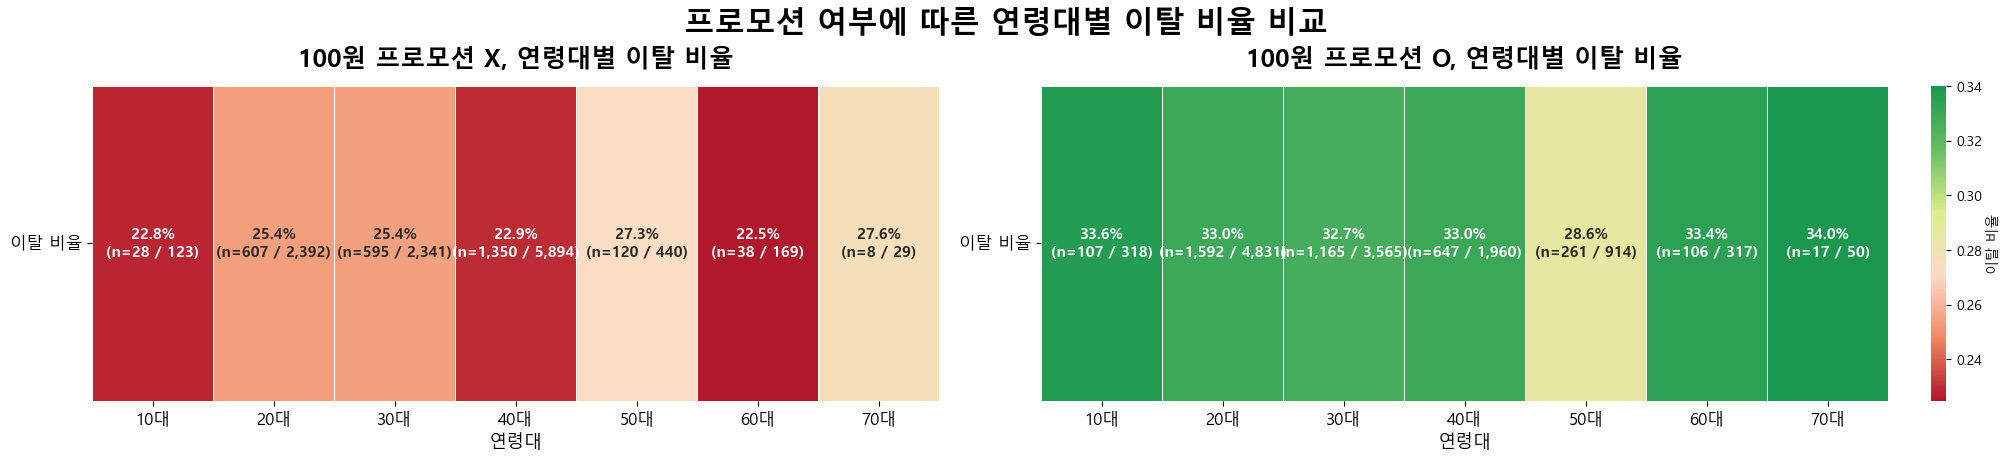

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 공통 컬러맵 설정
cmap = LinearSegmentedColormap.from_list(
    "custom_rgy",
    ["#b2182b", "#ef8a62", "#fddbc7", "#d9ef8b", "#66bd63", "#1a9850"]
)

# 연령대 구간 정의
age_bins = [10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]


def prepare_age_heatmap_data(df, event_value=0):
    # 기본 전처리
    temp = df.copy()
    temp = temp[temp["age"].notna() & temp["is_repurchase"].notna()].copy()

    # 나이 숫자형 변환
    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp = temp[temp["age"].notna()].copy()

    # 연령대 생성
    temp["age_group"] = pd.cut(
        temp["age"],
        bins=age_bins,
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    # 연령대별 집계
    summary = (
        temp.groupby("age_group", observed=False)["is_repurchase"]
        .agg(
            event_cnt=lambda x: (x == event_value).sum(),
            total_cnt="count"
        )
        .reset_index()
    )

    # 비율 계산
    summary["rate"] = summary["event_cnt"] / summary["total_cnt"]

    # 정렬 보장
    summary["age_group"] = pd.Categorical(
        summary["age_group"],
        categories=age_labels,
        ordered=True
    )
    summary = summary.sort_values("age_group").reset_index(drop=True)

    # 히트맵용 1행 데이터 생성
    heatmap_data = pd.DataFrame([summary["rate"].values], columns=summary["age_group"])
    heatmap_data.index = ["이탈 비율"]

    # 셀 주석 데이터 생성
    annot_labels = [
        f"{rate:.1%}\n(n={event_cnt:,} / {total_cnt:,})"
        if pd.notna(rate) else ""
        for rate, event_cnt, total_cnt in zip(
            summary["rate"],
            summary["event_cnt"],
            summary["total_cnt"]
        )
    ]
    annot_data = pd.DataFrame([annot_labels], columns=summary["age_group"])
    annot_data.index = ["이탈 비율"]

    return heatmap_data, annot_data


# 비교 대상 데이터 준비
# event_value=0 -> 이탈 비율 기준
heatmap_0, annot_0 = prepare_age_heatmap_data(membership_0, event_value=0)
heatmap_1, annot_1 = prepare_age_heatmap_data(membership_1, event_value=0)

# 두 그림의 색상 범위 통일
combined_values = np.concatenate([
    heatmap_0.values.flatten(),
    heatmap_1.values.flatten()
])
combined_values = combined_values[~np.isnan(combined_values)]

vmin = combined_values.min()
vmax = combined_values.max()

if np.isclose(vmin, vmax):
    vmin = max(0, vmin - 0.05)
    vmax = min(1, vmax + 0.05)

# 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(20, 4.5), constrained_layout=True)

# 왼쪽 히트맵
sns.heatmap(
    heatmap_0,
    annot=annot_0,
    fmt="",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    ax=axes[0],
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)
axes[0].set_title("100원 프로모션 X, 연령대별 이탈 비율", fontsize=18, pad=14, weight="bold")
axes[0].set_xlabel("연령대", fontsize=13)
axes[0].set_ylabel("")
axes[0].tick_params(axis="x", labelsize=12)
axes[0].tick_params(axis="y", labelsize=12, rotation=0)

# 오른쪽 히트맵
sns.heatmap(
    heatmap_1,
    annot=annot_1,
    fmt="",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "이탈 비율"},
    ax=axes[1],
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)
axes[1].set_title("100원 프로모션 O, 연령대별 이탈 비율", fontsize=18, pad=14, weight="bold")
axes[1].set_xlabel("연령대", fontsize=13)
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=12)
axes[1].tick_params(axis="y", labelsize=12, rotation=0)

# 전체 제목
fig.suptitle("프로모션 여부에 따른 연령대별 이탈 비율 비교", fontsize=22, weight="bold")

plt.show()


In [23]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05
confidence_level = int((1 - alpha) * 100)

age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

def preprocess(df):
    temp = df.copy()

    # 필수 컬럼 결측 제거
    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna()
    ].copy()

    # 나이 숫자형 변환
    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp = temp[temp["age"].notna()].copy()

    # 나이대 구간화
    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    # 이탈 여부 생성
    temp["churn"] = (temp["is_repurchase"].astype(int) == 0).astype(int)

    return temp

def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    # 표본 크기 기반 검정 방식 선택
    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

df0 = preprocess(membership_0)
df1 = preprocess(membership_1)

g0 = (
    df0.groupby("age_group", observed=False)["churn"]
    .agg(churn_n="sum", total_n="count")
    .reset_index()
    .rename(columns={"churn_n": "churn_0", "total_n": "total_0"})
)

g1 = (
    df1.groupby("age_group", observed=False)["churn"]
    .agg(churn_n="sum", total_n="count")
    .reset_index()
    .rename(columns={"churn_n": "churn_1", "total_n": "total_1"})
)

merged = pd.merge(g0, g1, on="age_group", how="inner")

merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=age_labels,
    ordered=True
)
merged = merged.sort_values("age_group").reset_index(drop=True)

significant_lines = []

for _, row in merged.iterrows():
    churn_0 = int(row["churn_0"])
    total_0 = int(row["total_0"])
    churn_1 = int(row["churn_1"])
    total_1 = int(row["total_1"])

    rate_0 = churn_0 / total_0
    rate_1 = churn_1 / total_1
    pvalue, test_name = run_test(churn_0, total_0, churn_1, total_1)

    if pvalue < alpha:
        line = (
            f"{row['age_group']} | "
            f"프로모션 X: {rate_0:.1%} | "
            f"프로모션 O: {rate_1:.1%} | "
            f"p-value={pvalue:.6g} | "
            f"검정법={test_name}"
        )
        significant_lines.append(line)

print(f"{confidence_level}% 신뢰수준에서 나이대별 이탈률 차이가 유의한 구간")

if significant_lines:
    for line in significant_lines:
        print(line)
else:
    print("없음")


95% 신뢰수준에서 나이대별 이탈률 차이가 유의한 구간
10대 | 프로모션 X: 22.8% | 프로모션 O: 33.6% | p-value=0.0261504 | 검정법=Two-proportion z-test
20대 | 프로모션 X: 25.4% | 프로모션 O: 33.0% | p-value=4.5047e-11 | 검정법=Two-proportion z-test
30대 | 프로모션 X: 25.4% | 프로모션 O: 32.7% | p-value=2.39098e-09 | 검정법=Two-proportion z-test
40대 | 프로모션 X: 22.9% | 프로모션 O: 33.0% | p-value=5.56195e-19 | 검정법=Two-proportion z-test
60대 | 프로모션 X: 22.5% | 프로모션 O: 33.4% | p-value=0.0117858 | 검정법=Two-proportion z-test


In [24]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05
confidence_level = int((1 - alpha) * 100)

age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]
target_age_groups = ["20대", "30대", "50대"]


def preprocess_for_prevented(df):
    temp = df.copy()

    # 결측 제거
    temp = temp[
        temp["age"].notna() &
        temp["is_churn_prevented"].notna()
    ].copy()

    # 나이 숫자형 변환
    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp = temp[temp["age"].notna()].copy()

    # 연령대 구간화
    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    # 대상 연령대 필터링
    temp = temp[temp["age_group"].isin(target_age_groups)].copy()

    # 이탈방지 여부 정규화
    temp["is_churn_prevented"] = pd.to_numeric(
        temp["is_churn_prevented"],
        errors="coerce"
    )
    temp = temp[temp["is_churn_prevented"].isin([0, 1])].copy()
    temp["prevented"] = temp["is_churn_prevented"].astype(int)

    return temp


def run_test(success_0, total_0, success_1, total_1):
    nonsuccess_0 = total_0 - success_0
    nonsuccess_1 = total_1 - success_1

    small_sample_flag = (
        min(success_0, nonsuccess_0, success_1, nonsuccess_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[success_0, nonsuccess_0], [success_1, nonsuccess_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[success_0, success_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name


df0 = preprocess_for_prevented(membership_0)
df1 = preprocess_for_prevented(membership_1)

g0 = (
    df0.groupby("age_group", observed=True)["prevented"]
    .agg(prevented_0="sum", total_0="count")
    .reset_index()
)

g1 = (
    df1.groupby("age_group", observed=True)["prevented"]
    .agg(prevented_1="sum", total_1="count")
    .reset_index()
)

merged = pd.merge(g0, g1, on="age_group", how="inner")

# 표본 수 0 제거
merged = merged[
    (merged["total_0"] > 0) &
    (merged["total_1"] > 0)
].copy()

merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=target_age_groups,
    ordered=True
)

merged = merged.sort_values("age_group").reset_index(drop=True)

print(f"{confidence_level}% 신뢰수준에서 연령대별 is_churn_prevented 차이 검정 결과")

result_lines = []

for _, row in merged.iterrows():
    prevented_0 = int(row["prevented_0"])
    total_0 = int(row["total_0"])
    prevented_1 = int(row["prevented_1"])
    total_1 = int(row["total_1"])

    # 0으로 나누기 방지
    if total_0 == 0 or total_1 == 0:
        continue

    rate_0 = prevented_0 / total_0
    rate_1 = prevented_1 / total_1
    diff = rate_1 - rate_0

    pvalue, test_name = run_test(prevented_0, total_0, prevented_1, total_1)
    significance = "유의미함" if pvalue < alpha else "유의미하지 않음"

    line = (
        f"{row['age_group']} | "
        f"프로모션 X: {rate_0:.1%} ({prevented_0}/{total_0}) | "
        f"프로모션 O: {rate_1:.1%} ({prevented_1}/{total_1}) | "
        f"차이(O-X): {diff:+.1%} | "
        f"p-value={pvalue:.6g} | "
        f"검정법={test_name} | "
        f"판정={significance}"
    )
    result_lines.append(line)

if result_lines:
    for line in result_lines:
        print(line)
else:
    print("비교 가능한 구간 없음")


95% 신뢰수준에서 연령대별 is_churn_prevented 차이 검정 결과
20대 | 프로모션 X: 29.8% (712/2392) | 프로모션 O: 14.9% (722/4831) | 차이(O-X): -14.8% | p-value=5.8934e-50 | 검정법=Two-proportion z-test | 판정=유의미함
30대 | 프로모션 X: 28.3% (663/2341) | 프로모션 O: 16.5% (588/3565) | 차이(O-X): -11.8% | p-value=1.41437e-27 | 검정법=Two-proportion z-test | 판정=유의미함
50대 | 프로모션 X: 27.3% (120/440) | 프로모션 O: 13.5% (123/914) | 차이(O-X): -13.8% | p-value=5.48453e-10 | 검정법=Two-proportion z-test | 판정=유의미함
